In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Lambda
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2716s 16us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [4]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [5]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

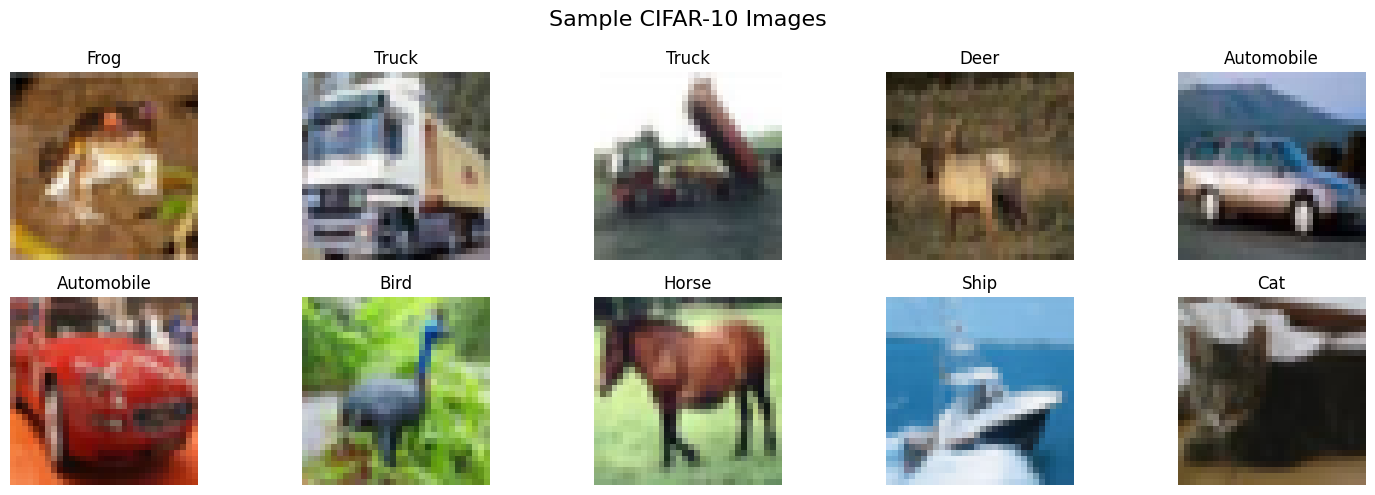

In [6]:
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
IMG_SIZE = 96
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the pretrained convolutional base
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [29]:
inputs = Input(shape=(32, 32, 3))

# Resize CIFAR-10 images
x = tf.keras.layers.Resizing(
    IMG_SIZE,
    IMG_SIZE
)(inputs)

# MobileNetV2 expects values approximately between -1 and 1
x = Lambda(lambda x: x * 2.0 - 1.0)(x)

# Pretrained convolutional base
x = base_model(x, training=False)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Dense Layer with ReLU
x = Dense(
    128,
    activation="relu"
)(x)

# Dropout for regularization
x = Dropout(0.3)(x)

# Output layer
outputs = Dense(
    10,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
EPOCHS = 15
BATCH_SIZE = 32

history_initial = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.7966 - loss: 0.6064 - val_accuracy: 0.8497 - val_loss: 0.4329
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8476 - loss: 0.4427 - val_accuracy: 0.8627 - val_loss: 0.4014
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8637 - loss: 0.3897 - val_accuracy: 0.8661 - val_loss: 0.3936
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8748 - loss: 0.3592 - val_accuracy: 0.8658 - val_loss: 0.3987
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8851 - loss: 0.3309 - val_accuracy: 0.8705 - val_loss: 0.3912
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8934 - loss: 0.3058 - val_accuracy: 0.8680 - val_loss: 0.4021
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9006 - loss: 0.2818 - val_accuracy: 0.8649 - val_loss: 0.4126
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9071 -

In [12]:
test_loss_before, test_acc_before = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy Before Fine-Tuning:",
      round(test_acc_before * 100, 2), "%")

print("Test Loss Before Fine-Tuning:",
      round(test_loss_before, 4))

Test Accuracy Before Fine-Tuning: 86.24 %
Test Loss Before Fine-Tuning: 0.5257


In [13]:
predictions_before = model.predict(x_test)

y_pred_before = np.argmax(predictions_before, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step


In [14]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print("Trainable layers:", trainable_layers)

Trainable layers: 20


In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
FINE_TUNE_EPOCHS = 7

history_finetune = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.8311 - loss: 0.7028 - val_accuracy: 0.8507 - val_loss: 0.4706
Epoch 2/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8965 - loss: 0.3027 - val_accuracy: 0.8646 - val_loss: 0.4716
Epoch 3/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9150 - loss: 0.2468 - val_accuracy: 0.8784 - val_loss: 0.4166
Epoch 4/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9312 - loss: 0.1942 - val_accuracy: 0.8773 - val_loss: 0.4717
Epoch 5/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9413 - loss: 0.1716 - val_accuracy: 0.8685 - val_loss: 0.5369
Epoch 6/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9512 - loss: 0.1437 - val_accuracy: 0.8667 - val_loss: 0.5641
Epoch 7/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9567 - loss: 0.1268 - val_accuracy: 0.8771 - val_loss: 0.5207


In [17]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Final Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

print("Final Test Loss:",
      round(test_loss, 4))

predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

y_true = y_test.flatten()

Final Test Accuracy: 87.55 %
Final Test Loss: 0.5183
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


In [18]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8755
Precision: 0.8801
Recall   : 0.8755
F1 Score : 0.8752


In [19]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.85      0.93      0.89      1000
  Automobile       0.94      0.94      0.94      1000
        Bird       0.81      0.89      0.85      1000
         Cat       0.77      0.80      0.78      1000
        Deer       0.80      0.88      0.84      1000
         Dog       0.94      0.70      0.80      1000
        Frog       0.94      0.86      0.90      1000
       Horse       0.88      0.92      0.90      1000
        Ship       0.91      0.94      0.92      1000
       Truck       0.96      0.90      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



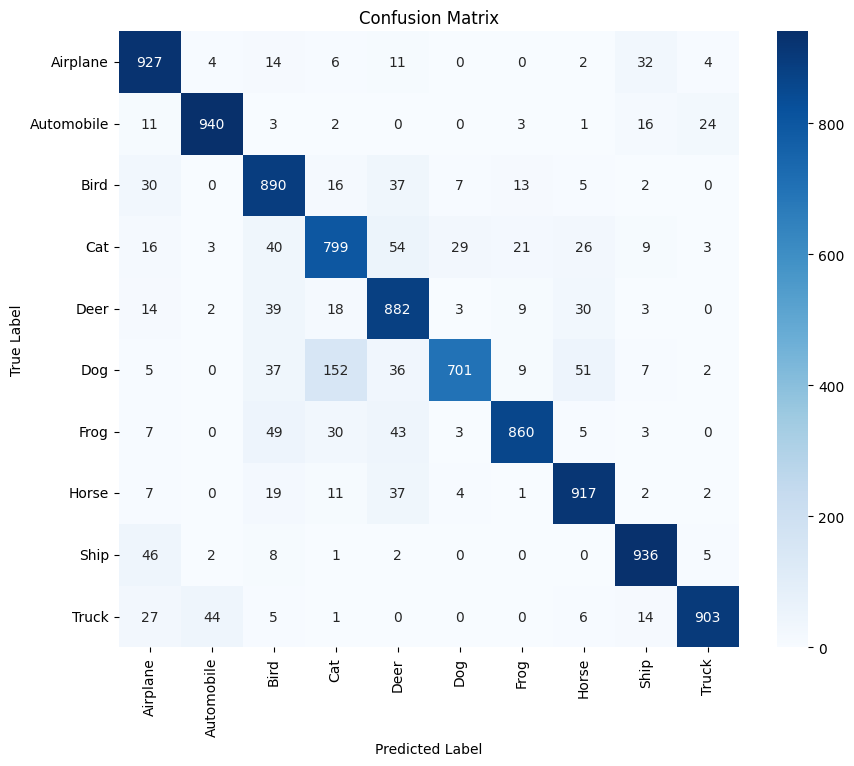

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

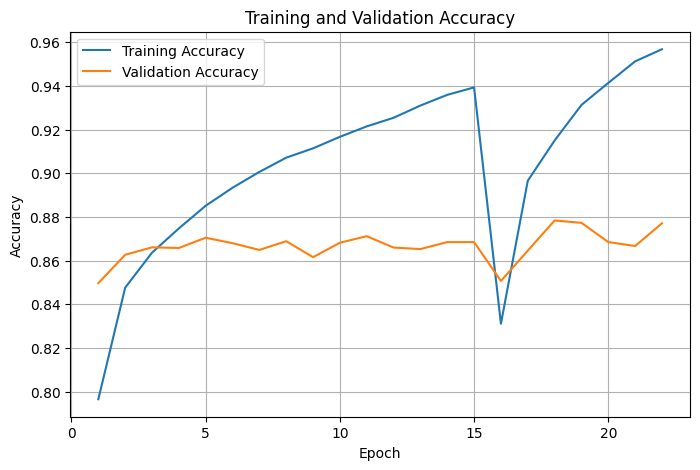

In [22]:
train_accuracy = (
    history_initial.history["accuracy"]
    + history_finetune.history["accuracy"]
)

val_accuracy = (
    history_initial.history["val_accuracy"]
    + history_finetune.history["val_accuracy"]
)

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

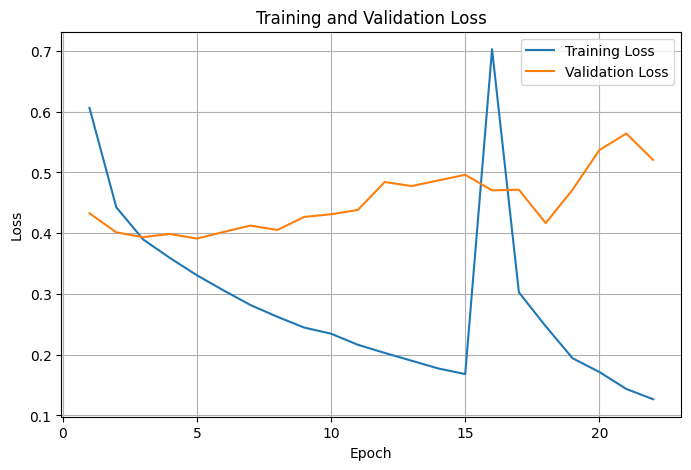

In [24]:
train_loss = (
    history_initial.history["loss"]
    + history_finetune.history["loss"]
)

val_loss = (
    history_initial.history["val_loss"]
    + history_finetune.history["val_loss"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

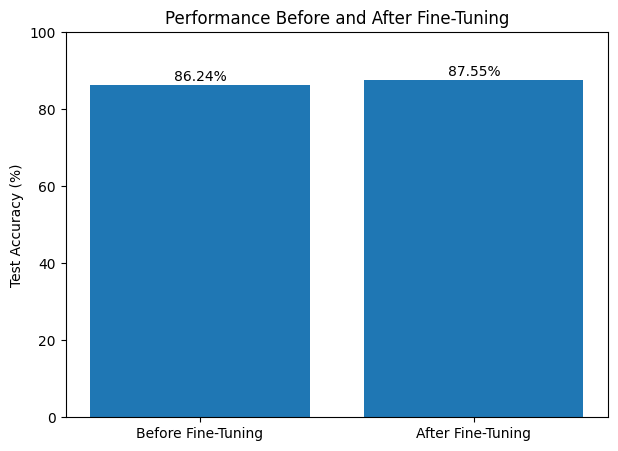

In [25]:
labels = [
    "Before Fine-Tuning",
    "After Fine-Tuning"
]

accuracies = [
    test_acc_before * 100,
    test_accuracy * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    accuracies
)

plt.ylabel("Test Accuracy (%)")

plt.title(
    "Performance Before and After Fine-Tuning"
)

plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

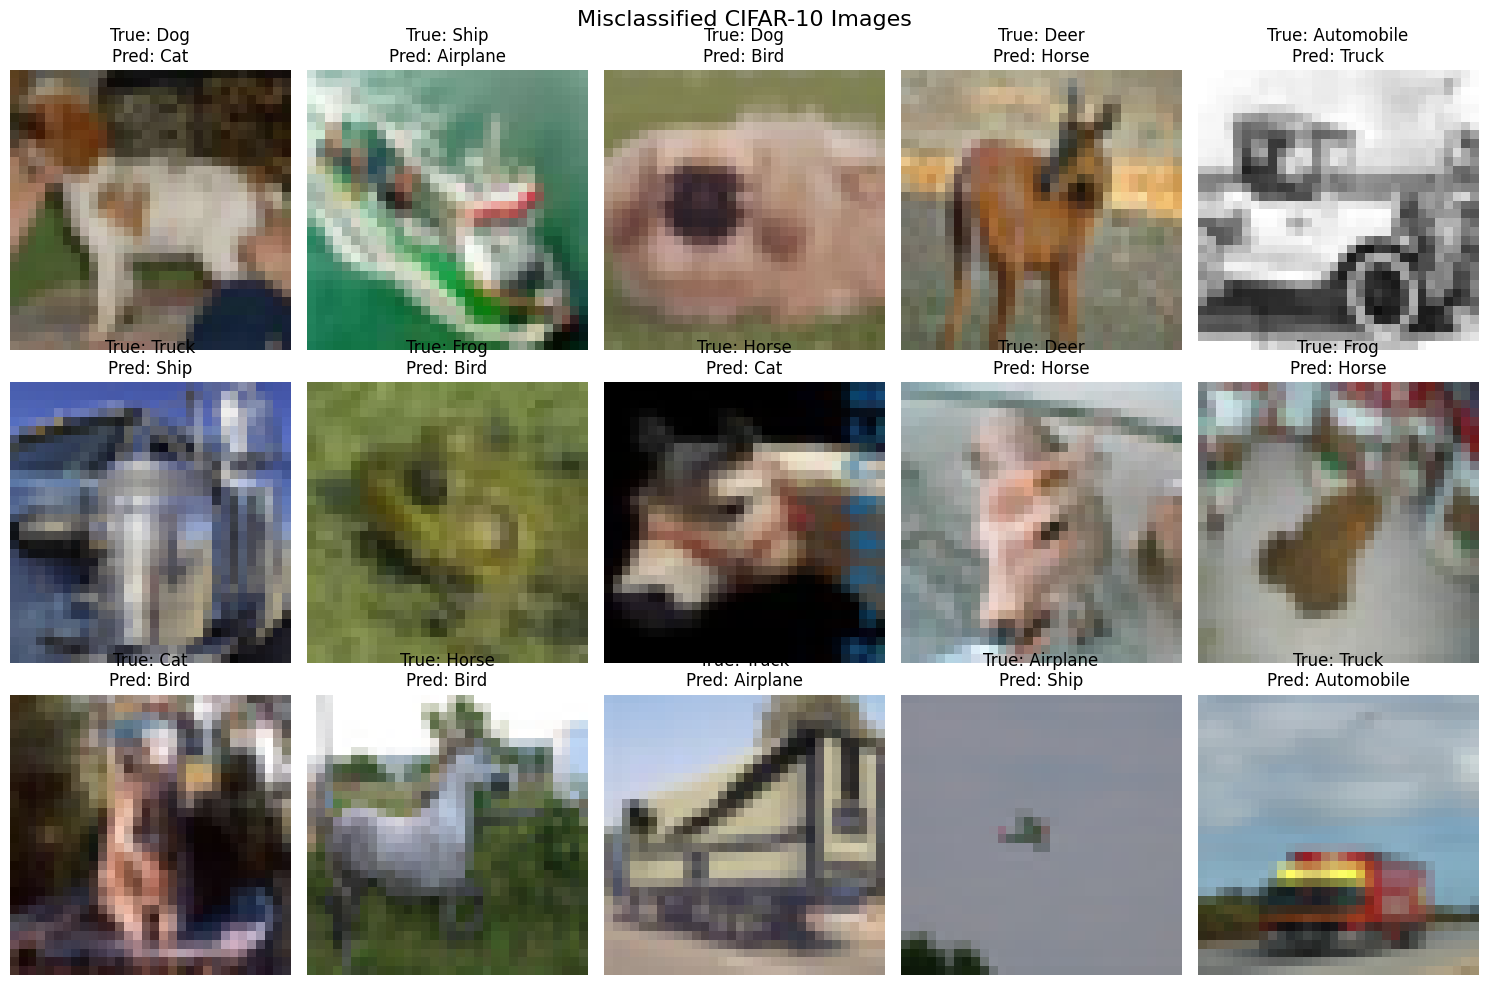

In [26]:
misclassified = np.where(
    y_true != y_pred
)[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(misclassified[:15]):

    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.suptitle(
    "Misclassified CIFAR-10 Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
total_params = model.count_params()
print("Total Parameters:", total_params)
training_accuracy = train_accuracy[-1]

print(
    "Final Training Accuracy:",
    round(training_accuracy * 100, 2),
    "%"
)

Total Parameters: 2423242
Final Training Accuracy: 95.67 %


In [28]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Total Parameters"
    ],

    "Value": [
        f"{training_accuracy * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        total_params
    ]
})

results

,Metric,Value
0,Training Accuracy,95.67%
1,Testing Accuracy,87.55%
2,Precision,0.8801
3,Recall,0.8755
4,F1-score,0.8752
5,Total Parameters,2423242
